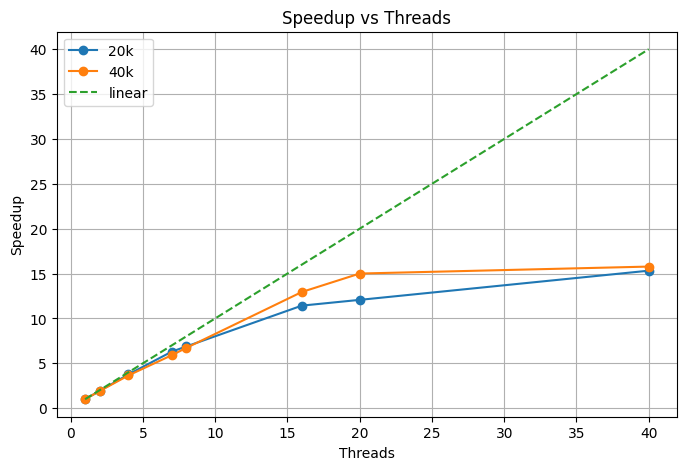

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dgemv/dgemv_time.csv')
df.columns = df.columns.str.strip()

q10 = df.groupby(['data_size', 'threads'])['time'].transform(lambda x: x.quantile(0.1))
q90 = df.groupby(['data_size', 'threads'])['time'].transform(lambda x: x.quantile(0.9))

df = df[(df['time'] >= q10) & (df['time'] <= q90)]
df = df.groupby(['data_size', 'threads'])['time'].mean().reset_index()
df['speedup'] = df.groupby('data_size')['time'].transform(lambda x: x.iloc[0] / x)
# разбиваем по data_size
df_20k = df[df['data_size'] == 20000]
df_40k = df[df['data_size'] == 40000]

# идеальная линейная линия
threads = sorted(df['threads'].unique())
ideal = threads  # S(p) = p


# plot
plt.figure(figsize=(8, 5))

plt.plot(df_20k['threads'], df_20k['speedup'], marker='o', label='20k')
plt.plot(df_40k['threads'], df_40k['speedup'], marker='o', label='40k')
plt.plot(threads, ideal, linestyle='--', label='linear')

plt.xlabel('Threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Threads')
plt.legend()
plt.grid(True)

plt.show()

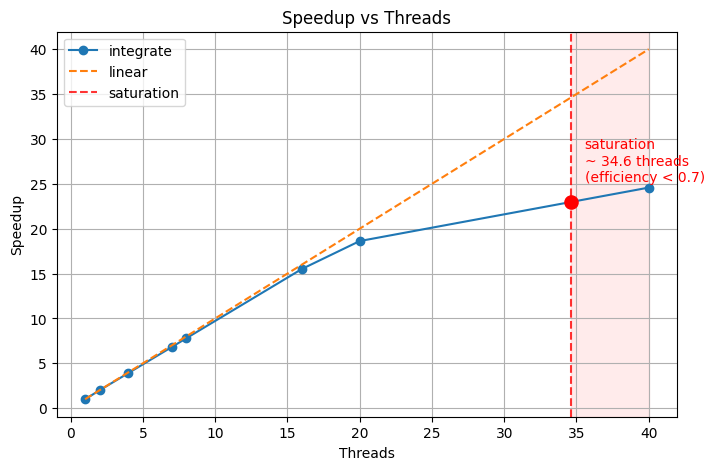

Estimated saturation point: 34.60 threads


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('integrate/integrate_time.csv')
df.columns = df.columns.str.strip()

q10 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.1))
q90 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.9))

df = df[(df['time'] >= q10) & (df['time'] <= q90)]
df = df.groupby('threads')['time'].mean().reset_index()

df['speedup'] = df['time'].transform(lambda x: x.iloc[0] / x)

# идеальная линейная линия
threads = df['threads'].to_numpy()
speedup = df['speedup'].to_numpy()
ideal = threads.astype(float)

# относительное отклонение от линейного ускорения:
# D_rel = (p - S(p)) / p = 1 - efficiency
df['rel_deviation'] = (threads - speedup) / threads

# порог насыщения: efficiency < 0.7  <=>  rel_deviation > 0.3
threshold = 0.3

# первый переход через порог
cross_idx = np.where(df['rel_deviation'].to_numpy() > threshold)[0]

p_sat = None
s_sat = None

if len(cross_idx) > 0:
    i2 = cross_idx[0]

    if i2 == 0:
        # если уже первая точка выше порога, интерполировать не с чем
        p_sat = threads[0]
        s_sat = speedup[0]
    else:
        i1 = i2 - 1

        p1, p2 = threads[i1], threads[i2]
        d1, d2 = df.loc[i1, 'rel_deviation'], df.loc[i2, 'rel_deviation']
        s1, s2 = speedup[i1], speedup[i2]

        # линейная интерполяция положения точки насыщения по rel_deviation
        if d2 != d1:
            alpha = (threshold - d1) / (d2 - d1)
            p_sat = p1 + alpha * (p2 - p1)
            s_sat = s1 + alpha * (s2 - s1)
        else:
            p_sat = p2
            s_sat = s2

# plot
plt.figure(figsize=(8, 5))

plt.plot(threads, speedup, marker='o', label='integrate')
plt.plot(threads, ideal, linestyle='--', label='linear')

if p_sat is not None and s_sat is not None:
    plt.axvline(p_sat, color='red', linestyle='--', alpha=0.8, label='saturation')
    plt.scatter(p_sat, s_sat, color='red', s=90, zorder=5)

    plt.annotate(
        f'saturation\n~ {p_sat:.1f} threads\n(efficiency < {1 - threshold})',
        xy=(p_sat, s_sat),
        xytext=(10, 15),
        textcoords='offset points',
        color='red'
    )

    plt.axvspan(p_sat, threads.max(), color='red', alpha=0.08)

plt.xlabel('Threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Threads')
plt.legend()
plt.grid(True)

plt.show()

if p_sat is not None:
    print(f'Estimated saturation point: {p_sat:.2f} threads')
else:
    print('Saturation point was not detected: rel_deviation never crossed the threshold.')

# SLAE
## Сравнение single omp section и multiple

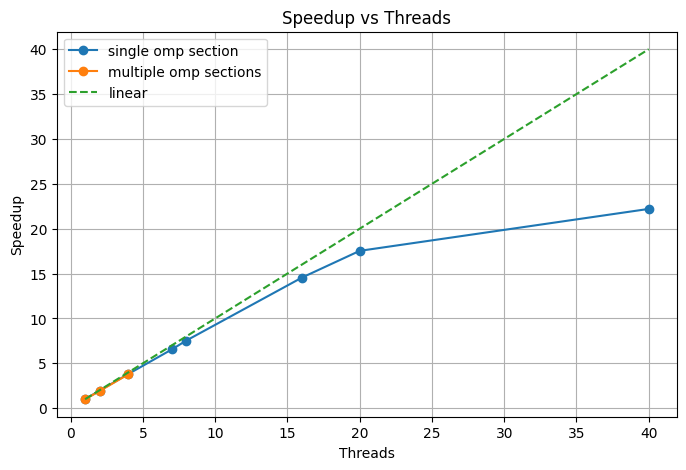

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def prepare_data(df):
    df.columns = df.columns.str.strip()

    q10 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.1))
    q90 = df.groupby('threads')['time'].transform(lambda x: x.quantile(0.9))

    df = df[(df['time'] >= q10) & (df['time'] <= q90)]
    df = df.groupby('threads')['time'].mean().reset_index()

    df['speedup'] = df['time'].transform(lambda x: x.iloc[0] / x)

    return df

df_single = pd.read_csv('slae/slae_single_block.csv')
df_multiple = pd.read_csv('slae/slae_multiple_blocks.csv')

df_single = prepare_data(df_single)
df_multiple = prepare_data(df_multiple)

# идеальная линейная линия
threads = sorted(df_single['threads'].unique())
ideal = threads  # S(p) = p

# plot
plt.figure(figsize=(8, 5))

plt.plot(df_single['threads'], df_single['speedup'], marker='o', label='single omp section')
plt.plot(df_multiple['threads'], df_multiple['speedup'], marker='o', label='multiple omp sections')
plt.plot(threads, ideal, linestyle='--', label='linear')

plt.xlabel('Threads')
plt.ylabel('Speedup')
plt.title('Speedup vs Threads')
plt.legend()
plt.grid(True)

plt.show()